In [ ]:
import pandas as pd

df = pd.read_csv('/content/netflix_titles.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
questions = [
    "1. How many Movies and TV Shows are in the dataset?",
    "2. Which year has the most Netflix titles?",
    "3. Which countries have the most Netflix titles?",
    "4. Which content ratings are most common?",
    "5. Are there missing values in the dataset?",
    "6. Are there duplicate records?"
]

for question in questions:
    print(question)

1. How many Movies and TV Shows are in the dataset?
2. Which year has the most Netflix titles?
3. Which countries have the most Netflix titles?
4. Which content ratings are most common?
5. Are there missing values in the dataset?
6. Are there duplicate records?


In [ ]:
df.shape

(8807, 12)

In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


In [ ]:
df['release_year'].value_counts().sort_values(ascending=False).head(10)

,count
release_year,
2018,1147
2017,1032
2019,1030
2020,953
2016,902
2021,592
2015,560
2014,352
2013,288


In [ ]:
country_counts = (
    df['country']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

country_counts

,count
country,
United States,3689
India,1046
United Kingdom,804
Canada,445
France,393
Japan,318
Spain,232
South Korea,231
Germany,226


In [ ]:
country_counts = (
    df['country']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

country_counts

,count
country,
United States,3689
India,1046
United Kingdom,804
Canada,445
France,393
Japan,318
Spain,232
South Korea,231
Germany,226


In [ ]:
df['rating'].value_counts().head(10)

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


In [ ]:
print("Oldest release year:", df['release_year'].min())
print("Newest release year:", df['release_year'].max())

Oldest release year: 1925
Newest release year: 2021


In [15]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [16]:
genre_counts = (
    df['listed_in']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

genre_counts

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


In [17]:
df['release_year'].sort_values().head(10)

,release_year
4250,1925
7790,1942
8205,1942
8739,1943
8763,1943
8660,1943
8419,1944
8436,1944
8640,1944
7219,1945


In [18]:
df['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


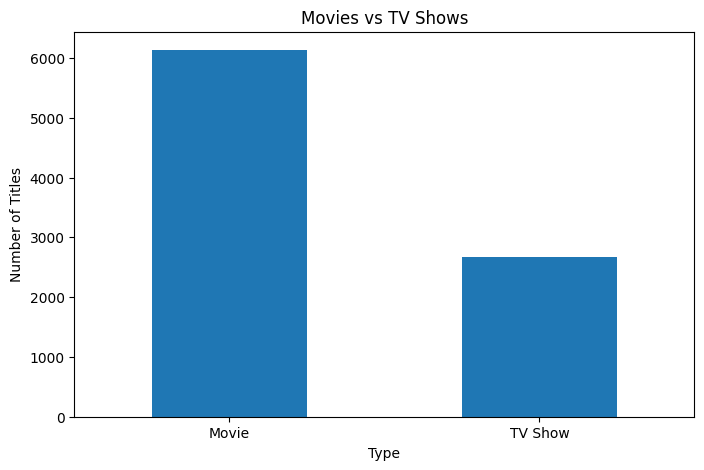

In [19]:
import matplotlib.pyplot as plt

type_counts = df['type'].value_counts()

plt.figure(figsize=(8, 5))
type_counts.plot(kind='bar')

plt.title('Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Number of Titles')
plt.xticks(rotation=0)

plt.show()

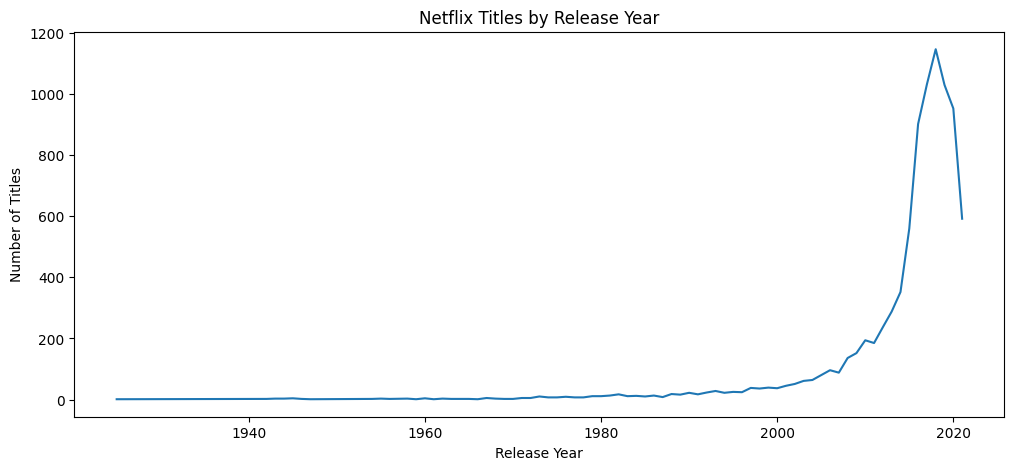

In [20]:
year_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(year_counts.index, year_counts.values)

plt.title('Netflix Titles by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.show()

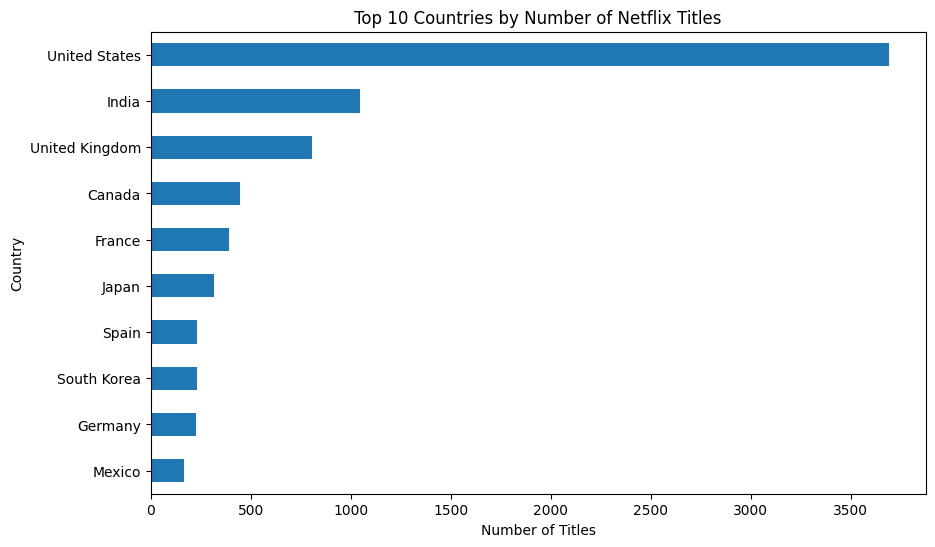

In [21]:
plt.figure(figsize=(10, 6))

country_counts.sort_values().plot(kind='barh')

plt.title('Top 10 Countries by Number of Netflix Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

plt.show()

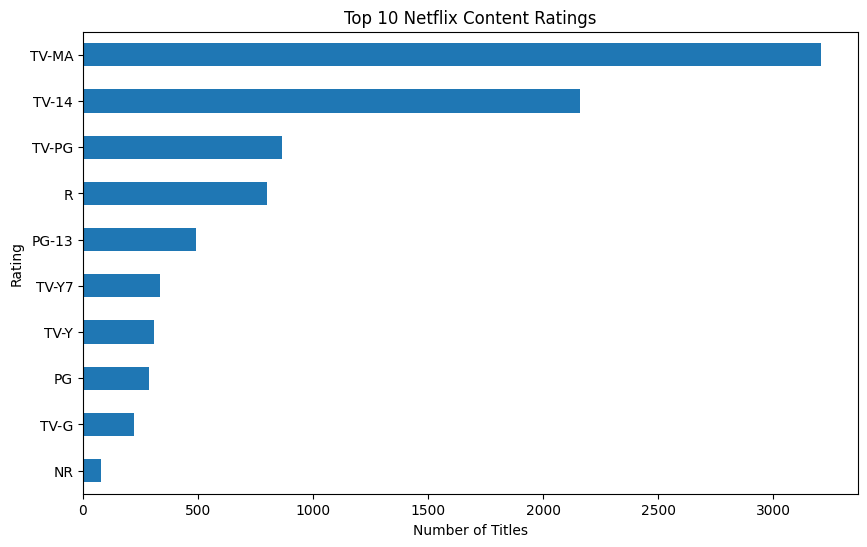

In [22]:
rating_counts = df['rating'].value_counts().head(10)

plt.figure(figsize=(10, 6))

rating_counts.sort_values().plot(kind='barh')

plt.title('Top 10 Netflix Content Ratings')
plt.xlabel('Number of Titles')
plt.ylabel('Rating')

plt.show()

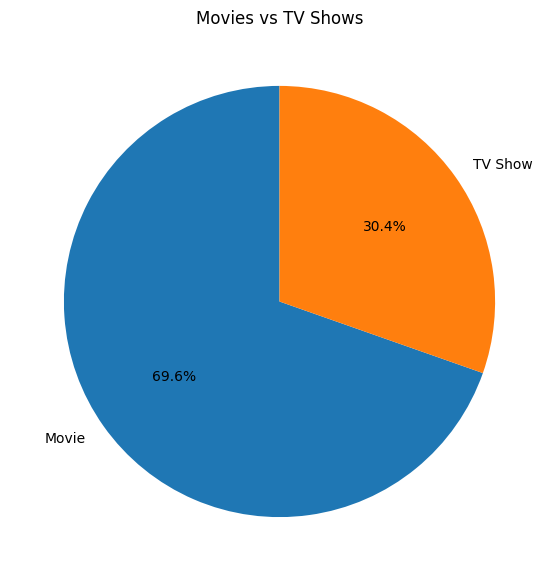

In [23]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    type_counts.values,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Movies vs TV Shows')
plt.show()

In [24]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage[missing_percentage > 0].sort_values(ascending=False)

,0
director,29.908028
country,9.435676
cast,9.367549
date_added,0.113546
rating,0.045418
duration,0.034064


In [25]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [26]:
type_year = df.groupby(['release_year', 'type']).size().unstack(fill_value=0)

type_year.tail(15)

type,Movie,TV Show
release_year,,
2007,74,14
2008,113,23
2009,118,34
2010,154,40
2011,145,40
2012,173,64
2013,225,63
2014,264,88
2015,398,162


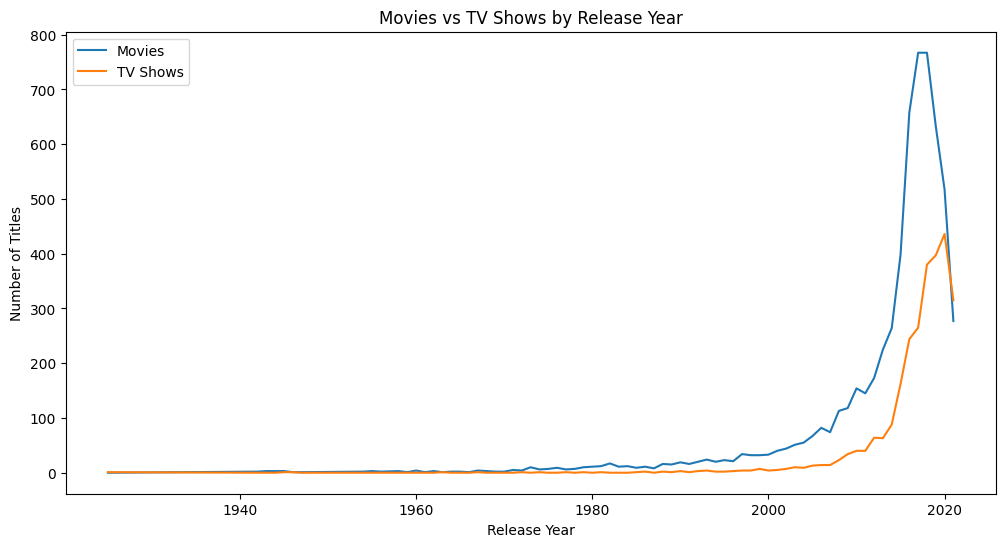

In [27]:
plt.figure(figsize=(12, 6))

plt.plot(type_year.index, type_year['Movie'], label='Movies')
plt.plot(type_year.index, type_year['TV Show'], label='TV Shows')

plt.title('Movies vs TV Shows by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.legend()
plt.show()

In [28]:
print("EDA FINDINGS")
print()
print("1. The dataset contains both Movies and TV Shows.")
print("2. The release-year analysis shows how Netflix titles are distributed over time.")
print("3. The country analysis identifies countries with the highest number of titles.")
print("4. The rating analysis shows the most common content ratings.")
print("5. The genre analysis identifies the most common content categories.")
print("6. Missing-value analysis identifies columns that need data cleaning.")
print("7. Duplicate analysis checks whether repeated records are present.")
print("8. The Movies vs TV Shows trend chart helps compare their distribution across release years.")

EDA FINDINGS

1. The dataset contains both Movies and TV Shows.
2. The release-year analysis shows how Netflix titles are distributed over time.
3. The country analysis identifies countries with the highest number of titles.
4. The rating analysis shows the most common content ratings.
5. The genre analysis identifies the most common content categories.
6. Missing-value analysis identifies columns that need data cleaning.
7. Duplicate analysis checks whether repeated records are present.
8. The Movies vs TV Shows trend chart helps compare their distribution across release years.


In [29]:
from scipy.stats import binomtest

movie_count = type_counts['Movie']
total_count = type_counts.sum()

result = binomtest(
    movie_count,
    n=total_count,
    p=0.5,
    alternative='two-sided'
)

print("Movie proportion:", movie_count / total_count)
print("P-value:", result.pvalue)

Movie proportion: 0.6961507891449983
P-value: 1.3720938819809653e-304
